Scanning directory: /projects/p32143/RL_human_decision/webscrape/social/SocialMedia_rewrite...
  Processed 2260 files. Found 1816 in range.
Scanning directory: /projects/p32143/RL_human_decision/webscrape/social/SocialMedia_Reddit...
  Processed 2260 files. Found 1850 in range.
Plot saved successfully as 'combined_length_distribution_single_plot.svg'


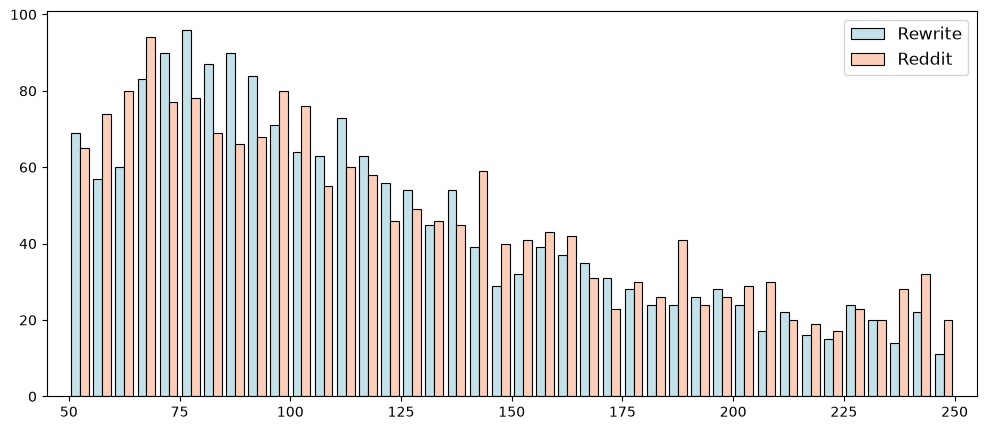

In [9]:
import os
import matplotlib.pyplot as plt

# 1. Define paths and parameters
DIR_REWRITE = "/projects/p32143/RL_human_decision/webscrape/social/SocialMedia_rewrite"
DIR_REDDIT = "/projects/p32143/RL_human_decision/webscrape/social/SocialMedia_Reddit"

OUTPUT_IMAGE = "combined_length_distribution_single_plot.svg"

MIN_WORDS = 50
MAX_WORDS = 250

def get_word_counts(dir_path):
    """Reads texts in the directory and returns filtered word counts."""
    filtered_lengths = []
    total_files = 0
    print(f"Scanning directory: {dir_path}...")
    
    for root, _, files in os.walk(dir_path):
        for file in files:
            if file.endswith(".txt"): 
                file_path = os.path.join(root, file)
                
                try:
                    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                        text = f.read()
                        word_count = len(text.split())
                        total_files += 1
                        
                        if MIN_WORDS <= word_count <= MAX_WORDS:
                            filtered_lengths.append(word_count)
                            
                except Exception as e:
                    print(f"Error reading {file}: {e}")
                    
    print(f"  Processed {total_files} files. Found {len(filtered_lengths)} in range.")
    return filtered_lengths

# 2. Extract data from both directories
lengths_rewrite = get_word_counts(DIR_REWRITE)
lengths_reddit = get_word_counts(DIR_REDDIT)

# 3. Create a single plot
plt.figure(figsize=(12, 5))

# Passing a list of arrays to plt.hist plots them side-by-side in each bin interval
plt.hist(
    [lengths_rewrite, lengths_reddit], 
    bins=40, 
    color=['#c4e0e8', '#fbcfbb'], # Khaki and Pale Green
    edgecolor='black', 
    linewidth=0.8,
    label=['Rewrite', 'Reddit']
)

# 4. Format the chart
plt.xlim(45, 255)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Add a legend so you know which color is which
plt.legend(loc='upper right', fontsize=12)

# Save the figure
plt.savefig(OUTPUT_IMAGE, dpi=300, bbox_inches='tight')
print(f"Plot saved successfully as '{OUTPUT_IMAGE}'")

Scanning directory: /projects/p32143/RL_human_decision/webscrape/social/SocialMedia_Reddit...
Processed 2260 total files.
Found 1850 files between 50 and 250 words. Generating plot...
Plot saved successfully as 'length_distribution_50_250.svg'


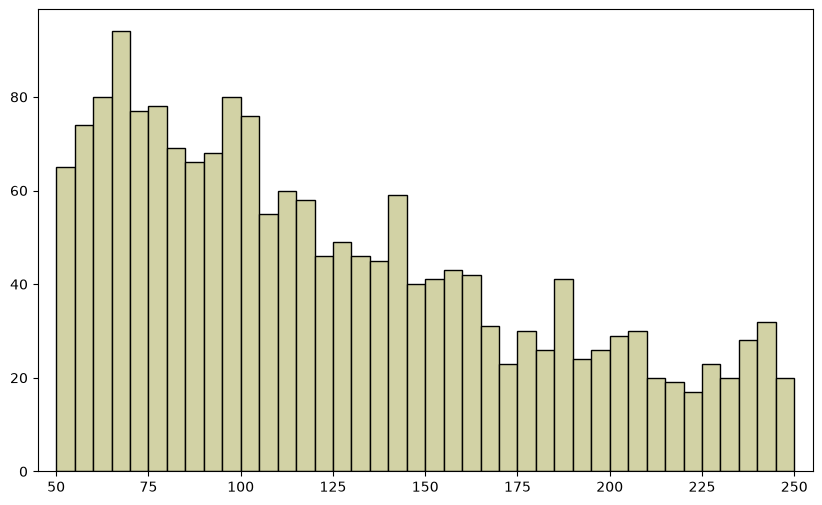

In [1]:
import os
import matplotlib.pyplot as plt

# 1. Define paths and parameters
# DIR_PATH = "/projects/p32143/RL_human_decision/webscrape/social/SocialMedia_rewrite"
DIR_PATH = "/projects/p32143/RL_human_decision/webscrape/social/SocialMedia_Reddit"

OUTPUT_IMAGE = "length_distribution_50_250.svg"

MIN_WORDS = 50
MAX_WORDS = 250

filtered_lengths = []
total_files = 0

print(f"Scanning directory: {DIR_PATH}...")

# 2. Read files and calculate lengths
for root, _, files in os.walk(DIR_PATH):
    for file in files:
        if file.endswith(".txt"): 
            file_path = os.path.join(root, file)
            
            try:
                with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                    text = f.read()
                    
                    word_count = len(text.split())
                    total_files += 1
                    
                    # Only keep the length if it falls within the target range
                    if MIN_WORDS <= word_count <= MAX_WORDS:
                        filtered_lengths.append(word_count)
                    
            except Exception as e:
                print(f"Error reading {file}: {e}")

if not filtered_lengths:
    print(f"Checked {total_files} files, but none were between {MIN_WORDS} and {MAX_WORDS} words.")
else:
    print(f"Processed {total_files} total files.")
    print(f"Found {len(filtered_lengths)} files between {MIN_WORDS} and {MAX_WORDS} words. Generating plot...")

    # 3. Plot the distribution
    plt.figure(figsize=(10, 6))
    
    # Bins set to 40 so each bar represents a 5-word range ((250-50)/40 = 5)
    plt.hist(filtered_lengths, bins=40, color='#D2D2A5', edgecolor='black')
    
    plt.title(f'')
    plt.xlabel('')
    plt.ylabel('')

    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    
    # Set x-axis limits to exactly match our target range
    plt.xlim(45, 255)
    # plt.grid(axis='y', alpha=0.75)
    
    # Save the figure
    plt.savefig(OUTPUT_IMAGE, dpi=300, bbox_inches='tight')
    print(f"Plot saved successfully as '{OUTPUT_IMAGE}'")

In [7]:
import os


def clean_text_files(folder_path):
    count = 0
    # Check if the folder exists
    if not os.path.exists(folder_path):
        print(f"Error: The folder '{folder_path}' does not exist.")
        return
    # Iterate through all files in the directory
    for filename in os.listdir(folder_path):
        # Process only .txt files
        if filename.endswith(".txt"):
            filepath = os.path.join(folder_path, filename)
            
            try:
                # Read the file content
                with open(filepath, 'r', encoding='utf-8') as file:
                    text = file.read()
                
                # 1. Check Word Count
                word_count = len(text.split())
                if "casual" in text.lower():
                    count += 1
                    print(f"Removing '{filename}': Contains the word 'casual'.")
                    os.remove(filepath)
                    continue  # Skip to the next file

            except Exception as e:
                print(f"Error processing '{filename}': {e}")
    print(f"Total files removed: {count}")

# Run the function on your specific folder
clean_text_files('SocialMedia_rewrite_explanation_claude')


Total files removed: 0


In [1]:
import os
from langdetect import detect, LangDetectException

def clean_text_files(folder_path):
    # Check if the folder exists
    if not os.path.exists(folder_path):
        print(f"Error: The folder '{folder_path}' does not exist.")
        return

    # Iterate through all files in the directory
    for filename in os.listdir(folder_path):
        # Process only .txt files
        if filename.endswith(".txt"):
            filepath = os.path.join(folder_path, filename)
            
            try:
                # Read the file content
                with open(filepath, 'r', encoding='utf-8') as file:
                    text = file.read()
                
                # 1. Check Word Count
                word_count = len(text.split())
                # if "translate" in text.lower():
                #     print(f"Removing '{filename}': Contains the word 'translate'.")
                #     os.remove(filepath)
                #     continue  # Skip to the next file
                if word_count > 250 or word_count < 20:
                    print(f"Removing '{filename}': Word count is {word_count} (Over 250 or Under 20).")
                    os.remove(filepath)
                    continue  # Skip to the next file

                # 2. Check Language
                # If the file is empty or only contains numbers/punctuation, detection might fail
                if text.strip():
                    detected_lang = detect(text)
                    if detected_lang != 'en':
                        print(f"Removing '{filename}': Language is not English (Detected '{detected_lang}').")
                        os.remove(filepath)
                else:
                    # Optional: Remove empty files
                    print(f"Removing '{filename}': File is empty.")
                    os.remove(filepath)

            except LangDetectException:
                # Triggers if the text has no distinct language features (e.g., "12345")
                print(f"Removing '{filename}': Could not detect language.")
                os.remove(filepath)
            except Exception as e:
                print(f"Error processing '{filename}': {e}")

# Run the function on your specific folder
clean_text_files('SocialMedia_Reddit')

Removing 'reddit_9837.txt': Word count is 374 (Over 250 or Under 20).
Removing 'reddit_1413.txt': Word count is 257 (Over 250 or Under 20).
Removing 'reddit_25.txt': Word count is 19 (Over 250 or Under 20).
Removing 'reddit_1224.txt': Word count is 806 (Over 250 or Under 20).
Removing 'reddit_13.txt': Word count is 363 (Over 250 or Under 20).
Removing 'reddit_1638.txt': Word count is 607 (Over 250 or Under 20).
Removing 'reddit_1451.txt': Word count is 870 (Over 250 or Under 20).
Removing 'reddit_1528.txt': Word count is 7 (Over 250 or Under 20).
Removing 'reddit_2047.txt': Word count is 305 (Over 250 or Under 20).
Removing 'reddit_1526.txt': Word count is 496 (Over 250 or Under 20).
Removing 'reddit_3176.txt': Word count is 413 (Over 250 or Under 20).
Removing 'reddit_1369.txt': Word count is 412 (Over 250 or Under 20).
Removing 'reddit_136.txt': Word count is 331 (Over 250 or Under 20).
Removing 'reddit_1924.txt': Word count is 342 (Over 250 or Under 20).
Removing 'reddit_2162.txt': 

In [2]:
import os

def sync_target_folder(reference_folder, target_folder):
    # Verify both folders actually exist before doing anything
    if not os.path.exists(reference_folder):
        print(f"Error: The reference folder '{reference_folder}' does not exist.")
        return
    if not os.path.exists(target_folder):
        print(f"Error: The target folder '{target_folder}' does not exist.")
        return

    # 1. Get a list of all valid filenames from the reference folder
    # We use a 'set' here because it makes searching for names much faster
    valid_filenames = set(os.listdir(reference_folder))

    # 2. Iterate through all files in the target folder
    for filename in os.listdir(target_folder):
        # We only want to process .txt files
        if filename.endswith(".txt"):
            
            # 3. If the filename is NOT in our reference list, remove it
            if filename not in valid_filenames:
                filepath = os.path.join(target_folder, filename)
                print(f"Removing '{filename}': Not found in '{reference_folder}'.")
                
                try:
                    os.remove(filepath)
                except Exception as e:
                    print(f"Error deleting '{filename}': {e}")

# Run the function on your specific folders
# (Make sure these paths match exactly where your folders are located)
sync_target_folder('SocialMedia_Reddit', 'SocialMedia_Summary')
sync_target_folder('SocialMedia_Reddit', 'SocialMedia_Reddit_explanation')
sync_target_folder('SocialMedia_Reddit', 'SocialMedia_Reddit_explanation_claude')
sync_target_folder('SocialMedia_Reddit', 'SocialMedia_Reddit_explanation_gemini')
sync_target_folder('SocialMedia_Reddit', 'SocialMedia_rewrite')
sync_target_folder('SocialMedia_Reddit', 'SocialMedia_rewrite_explanation')
sync_target_folder('SocialMedia_Reddit', 'SocialMedia_rewrite_explanation_claude')
sync_target_folder('SocialMedia_Reddit', 'SocialMedia_rewrite_explanation_gemini')

Removing 'reddit_9837.txt': Not found in 'SocialMedia_Reddit'.
Removing 'reddit_8065.txt': Not found in 'SocialMedia_Reddit'.
Removing 'reddit_9867.txt': Not found in 'SocialMedia_Reddit'.
Removing 'reddit_8943.txt': Not found in 'SocialMedia_Reddit'.
Removing 'reddit_1413.txt': Not found in 'SocialMedia_Reddit'.
Removing 'reddit_8228.txt': Not found in 'SocialMedia_Reddit'.
Removing 'reddit_5470.txt': Not found in 'SocialMedia_Reddit'.
Removing 'reddit_3813.txt': Not found in 'SocialMedia_Reddit'.
Removing 'reddit_25.txt': Not found in 'SocialMedia_Reddit'.
Removing 'reddit_4326.txt': Not found in 'SocialMedia_Reddit'.
Removing 'reddit_9463.txt': Not found in 'SocialMedia_Reddit'.
Removing 'reddit_594.txt': Not found in 'SocialMedia_Reddit'.
Removing 'reddit_9118.txt': Not found in 'SocialMedia_Reddit'.
Removing 'reddit_1224.txt': Not found in 'SocialMedia_Reddit'.
Removing 'reddit_9156.txt': Not found in 'SocialMedia_Reddit'.
Removing 'reddit_8276.txt': Not found in 'SocialMedia_Redd